In [2]:
%load_ext autoreload
%autoreload 2

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

from utils import quality_metrics
# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

In [11]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [12]:
events = [14, 18, 24, 68]

In [13]:
df = pd.read_excel(os.path.join("../data/predicted_flood_depths_with_water_distance_2025-05-13.xlsx"))
df = df[
    df["measured_depth"]<4
]
df.shape
# Replace 0 values with 0.01 for all measured_depth
# df["measured_depth"] = df["measured_depth"].replace(0, 0.01)

(11740, 26)

In [14]:
df.head()

,VlogaId,Objekt_Naslov,Objekt_Naslov_PostnaStevilka,Objekt_Parcela_Stevilka,Objekt_Parcela_KoId,Objekt_UporabnaPovrsina,Objekt_VisinaVodeCm,Objekt_StopnjaPoskodovanosti,Skoda_DatumOcene,Objekt_VrstaObjektaId,DogodekId,Vrednost,OdstPoskodovanostiObjekta,SkupnaSkoda,SkupnaSkodaSource,geometry,gps_lat,gps_lng,predicted_wri_depth,predicted_si_depth,predicted_si_old_depth,predicted_wri_damage,predicted_si_damage,predicted_si_old_damage,measured_depth,distance_to_water
0,147651,Cesta med vinogradi 48,6000 KOPER - CAPODISTRIA,5743/6,715,50.0,30.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (405228.12739536207 46848.09332348127),45.555094,13.786126,0.000000,1.5,0.0,0.000000,0.500,0.0,0.3,52.066413
1,147686,Cesta med vinogradi 46,6000 KOPER - CAPODISTRIA,5743/10,715,55.0,50.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (405207.1266384774 46826.09359404445),45.554893,13.785861,0.000000,0.5,0.0,0.000000,0.250,0.0,0.5,77.663743
2,147692,Cesta med vinogradi 46,6000 KOPER - CAPODISTRIA,5743/10,715,38.0,50.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (405207.1266384774 46826.09359404445),45.554893,13.785861,0.000000,0.5,0.0,0.000000,0.250,0.0,0.5,77.663743
3,147704,Cesta med vinogradi 48,6000 KOPER - CAPODISTRIA,5743/6,715,80.0,40.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (405228.12739536207 46848.09332348127),45.555094,13.786126,0.000000,1.5,0.0,0.000000,0.500,0.0,0.4,52.066413
4,147723,Železniška cesta 8,6280 ANKARAN - ANCARANO,877/7,705,290.0,130.0,NaN,10/01/10 00:00:00,8.0,14,NaN,NaN,NaN,NaN,POINT (402903.1218190783 47653.158125260845),45.562016,13.756194,0.482443,2.5,0.0,0.241221,0.675,0.0,1.3,456.388682


In [16]:
df = df[[
    "VlogaId",
    "DogodekId",
    "gps_lat",
    "gps_lng",
    "measured_depth",
    "predicted_wri_depth",
    "predicted_si_depth",
    "distance_to_water",
]]

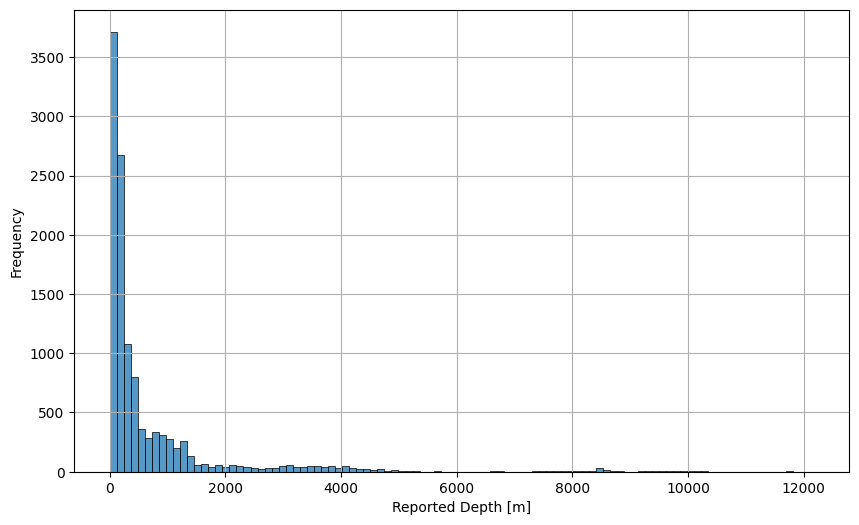

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df["distance_to_water"], bins=100)
plt.xlabel("Reported Depth [m]")
plt.ylabel("Frequency")
plt.grid(True)
# plt.xlim(0,4)
plt.show()

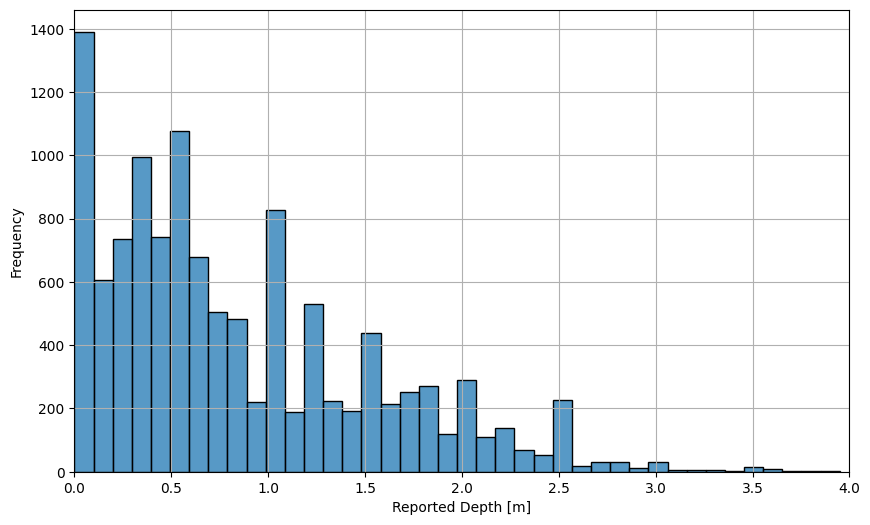

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df["measured_depth"], bins=40)
plt.xlabel("Reported Depth [m]")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0,4)
plt.show()

In [24]:
# Show number of samples, split by event
event_sample_counts = df["DogodekId"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)

df.shape

Number of samples split by event:
DogodekId
68    6568
14    2477
18    1797
24     898
Name: count, dtype: int64


(11740, 8)

In [25]:
# Calculate the errors
df["si_error"] = df["measured_depth"] - df["predicted_si_depth"]
df["wri_error"] = df["measured_depth"] - df["predicted_wri_depth"]

### Segmentation by flood event

In [26]:
print(f"Total")
_df = df.copy()
_df = _df[_df["distance_to_water"]<100]
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
print("-"*100)

for event_id in events:
    print(f"Event ID: {event_id}")
    _df = df.copy()
    _df = _df[_df["DogodekId"]==event_id]
    # _df = _df[_df["distance_to_water"]<100]
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
    print("-"*100)

Total
{'within_20': 0.1745206369840754, 'median_error': 0.3, 'median_absolute_error': 0.7, 'st_dev_residuals': 5.338024452926597, 'total_samples': 3077}
{'within_20': 0.07799805004874878, 'median_error': 0.7, 'median_absolute_error': 0.8, 'st_dev_residuals': 2.01500832627846, 'total_samples': 3077}
----------------------------------------------------------------------------------------------------
Event ID: 14
{'within_20': 0.3105590062111801, 'median_error': -0.5, 'median_absolute_error': 0.7, 'st_dev_residuals': 4.38568200273743, 'total_samples': 483}
{'within_20': 0.2443064182194617, 'median_error': 0.41735388338565826, 'median_absolute_error': 0.41735388338565826, 'st_dev_residuals': 0.49278141507632695, 'total_samples': 483}
----------------------------------------------------------------------------------------------------
Event ID: 18
{'within_20': 0.3787878787878788, 'median_error': -0.25, 'median_absolute_error': 0.7, 'st_dev_residuals': 3.6362288745431517, 'total_samples': 39

In [27]:
def plot_errors_histogram(df, true_column, predicted_column, title: str = "Histogram of Errors", ax=None):
    if ax is None:
        ax = plt.gca()
        
    errors = df[true_column] - df[predicted_column]
    ax.hist(errors, bins=30, edgecolor="black")
    ax.set_title(f"{title}")
    ax.set_xlabel("Error")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=1)
    
    median_error = errors.median()
    std_error = errors.std()
    ax.axvline(median_error, color="red", linestyle="dashed", linewidth=1)
    
    # Get the current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Place text in top right corner
    stats_text = f"Median: {median_error:.2f}\nStd: {std_error:.2f}"
    ax.text(
        xlim[1] * 0.95,  # x position (95% of the way to the right)
        ylim[1] * 0.95,  # y position (95% of the way to the top)
        stats_text,
        color="red",
        ha="right",  # horizontal alignment
        va="top",    # vertical alignment
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2)  # white background box
    )

<Axes: xlabel='measured_depth', ylabel='predicted_si_depth'>

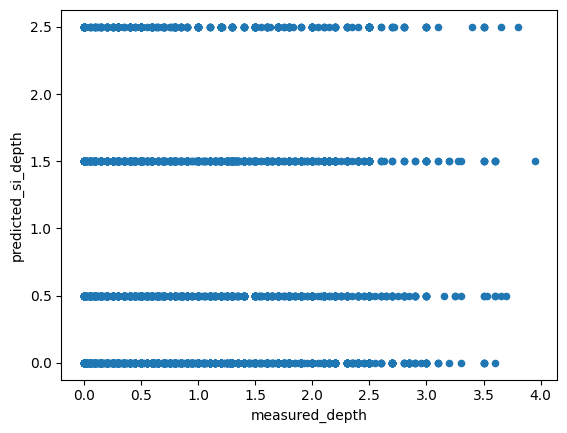

In [28]:
df.plot(x="measured_depth", y="predicted_si_depth", kind="scatter")

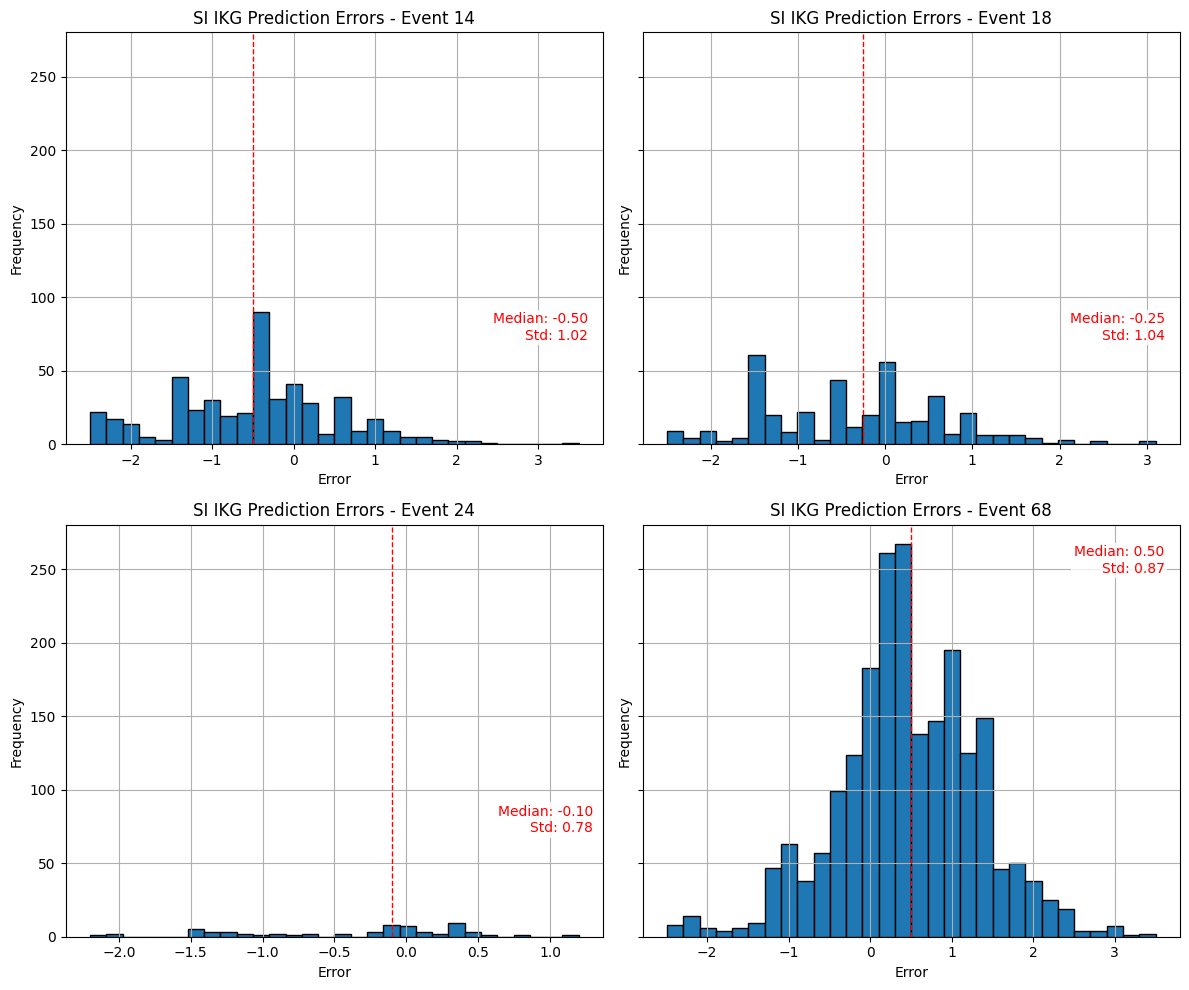

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_id in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekId"]==event_id]
    # _df = _df[_df["distance_to_water"]<100]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_si_depth",
        title=f"SI IKG Prediction Errors - Event {event_id}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.show()

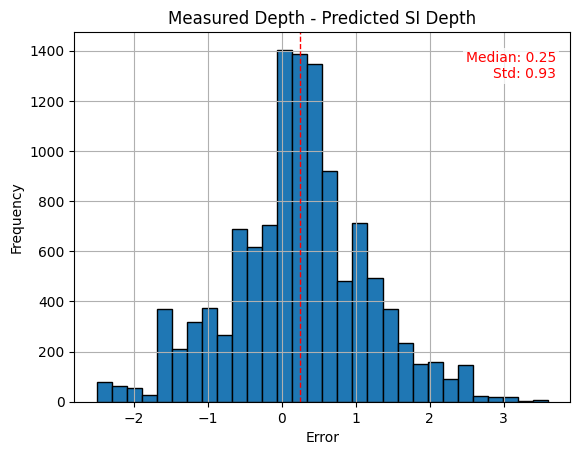

In [15]:
plot_errors_histogram(df, "measured_depth", "predicted_si_depth", title="Measured Depth - Predicted SI Depth")

<Axes: xlabel='measured_depth', ylabel='predicted_wri_depth'>

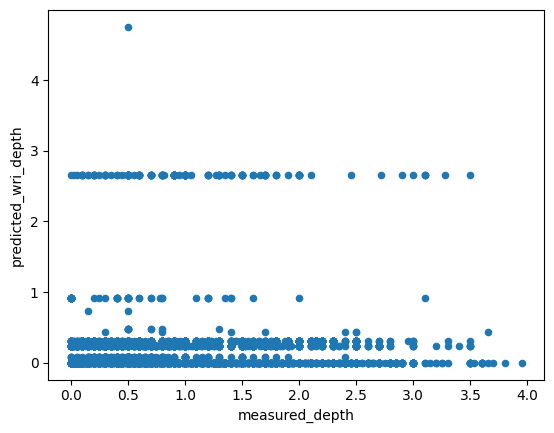

In [16]:
df.plot(x="measured_depth", y="predicted_wri_depth", kind="scatter")

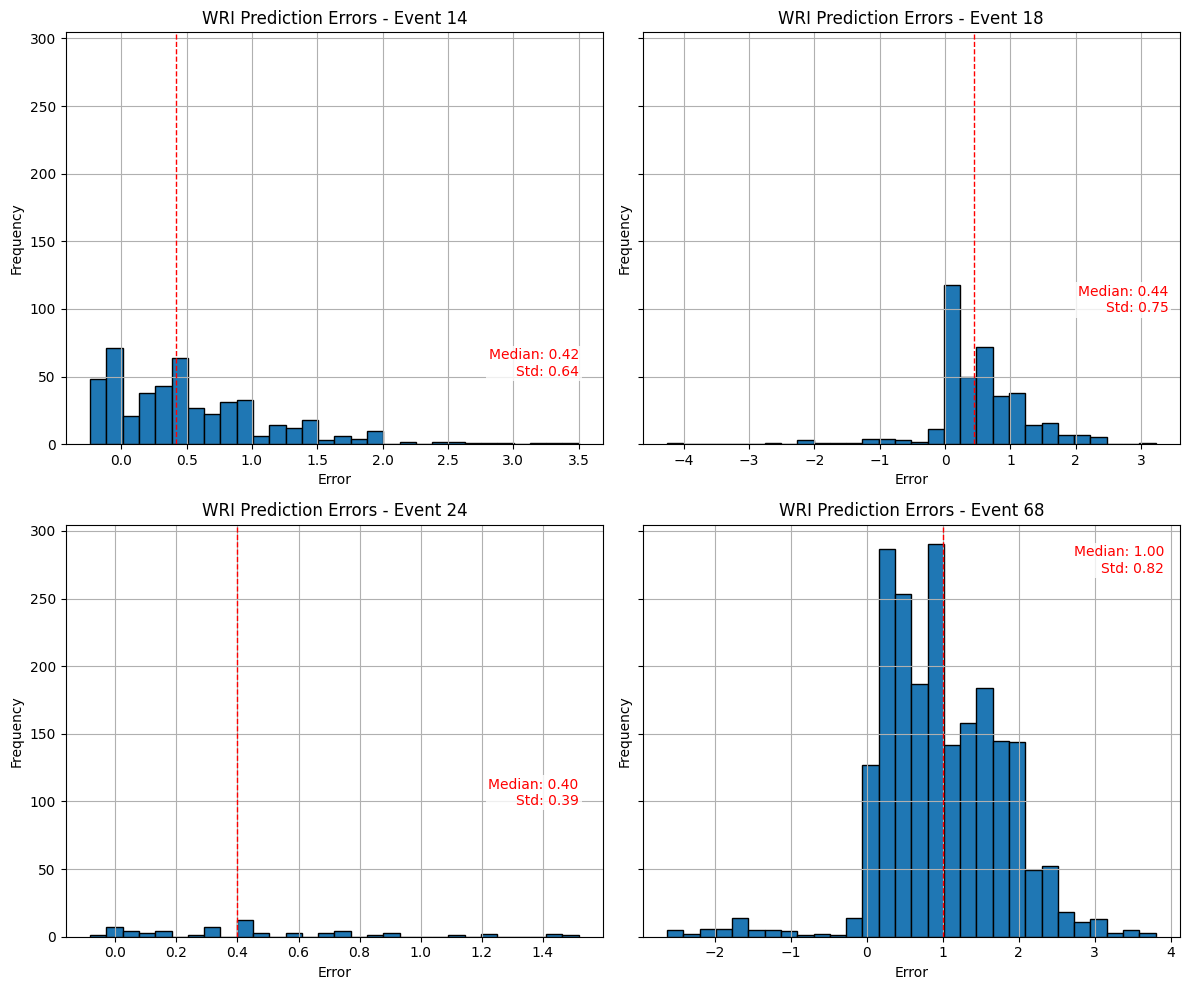

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_id in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekId"]==event_id]
    _df = _df[_df["distance_to_water"]<100]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_wri_depth",
        title=f"WRI Prediction Errors - Event {event_id}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.show()

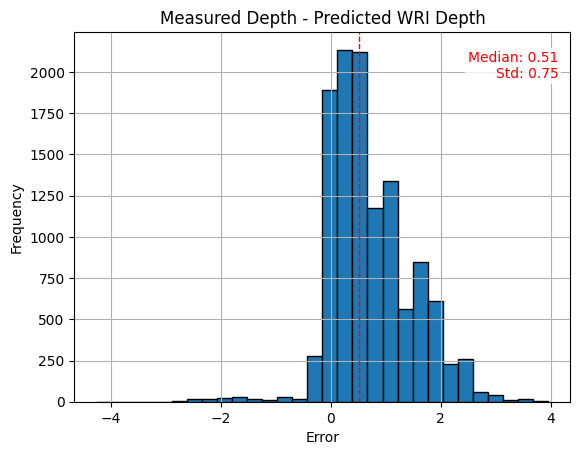

In [18]:
plot_errors_histogram(df, "measured_depth", "predicted_wri_depth", title="Measured Depth - Predicted WRI Depth")

{'si': {'within_20': 0.33831247476786436, 'median_error': -0.35, 'median_absolute_error': 0.5, 'st_dev_residuals': 3.772653726678259, 'total_samples': 2477}, 'wri': {'within_20': 0.2793702058942269, 'median_error': 0.35, 'median_absolute_error': 0.35, 'st_dev_residuals': 0.5279588283742902, 'total_samples': 2477}}
{'si': {'within_20': 0.3266555370061213, 'median_error': 0.0, 'median_absolute_error': 0.5, 'st_dev_residuals': 4.565795455921223, 'total_samples': 1797}, 'wri': {'within_20': 0.2632164718976071, 'median_error': 0.4, 'median_absolute_error': 0.5, 'st_dev_residuals': 0.8612658274295272, 'total_samples': 1797}}
{'si': {'within_20': 0.13251670378619154, 'median_error': 0.15, 'median_absolute_error': 0.365, 'st_dev_residuals': 2.748668518736592, 'total_samples': 898}, 'wri': {'within_20': 0.10356347438752785, 'median_error': 0.3, 'median_absolute_error': 0.3, 'st_dev_residuals': 0.5100186347488785, 'total_samples': 898}}
{'si': {'within_20': 0.10124847746650427, 'median_error': 0

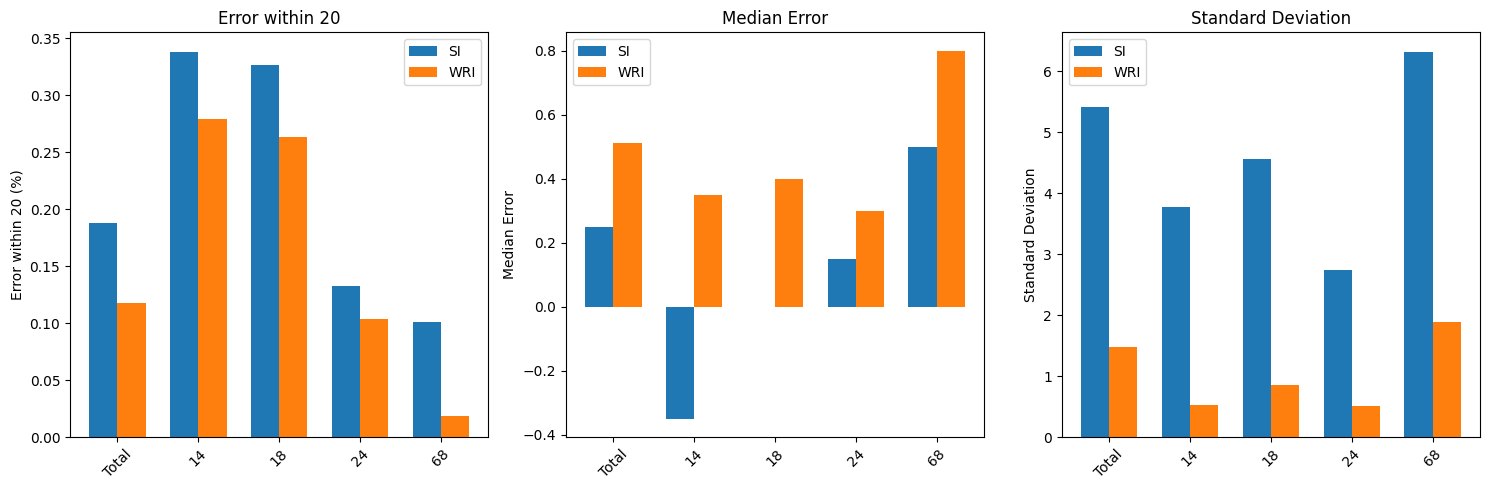

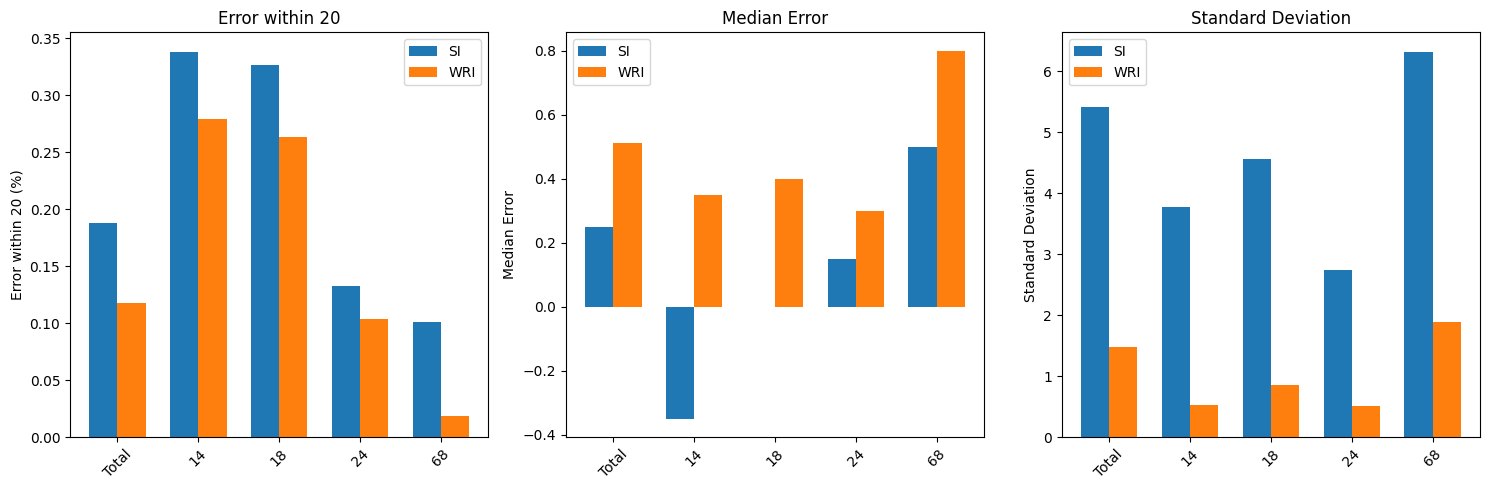

In [19]:
# TODO:
# - za vsak dogodek poračuna napako in odštej! Predpostavka: sistemski bias, zaradi intenzitete dogodka je napaka drugačna (različna intenziteta dogodka). Predpostavka je, da je sistematična napaka pri povezanih doogodkihj. Če to izničimo nan omogoča primerjavo med različnimi dogodki.
# - nov stolpec z bias_adjusted_prediction
# - segmentacija po različnih mestih / krajih - nov stolpec "Mesto"
#     - Zanimivo, zgoraj podcenjuejmo, zgoraj precenjujemo.
# - segmentacija po oddaljenosti od reke - nov stolpec "Oddaljenost od reke"

# Bias-adjusted columns

In [25]:
df["predicted_si_depth_bias_adjusted"] = df.groupby("DogodekId").apply(
    lambda x: (x["predicted_si_depth"] + (x["si_error"]).median()).clip(lower=0)
).reset_index(level=0, drop=True)


df["predicted_wri_depth_bias_adjusted"] = df.groupby("DogodekId").apply(
    lambda x: (x["predicted_wri_depth"] + (x["wri_error"]).median()).clip(lower=0)
).reset_index(level=0, drop=True)

In [30]:
df.tail(20)

,VlogaId,DogodekId,gps_lat,gps_lng,measured_depth,predicted_wri_depth,predicted_si_depth,si_error,wri_error,predicted_si_depth_bias_adjusted,predicted_wri_depth_bias_adjusted
13508,1456697,68,46.255995,15.099222,0.70,0.238227,0.0,0.70,0.461773,0.5,1.038227
13510,1456701,68,46.186888,14.598643,1.90,0.000000,0.5,1.40,1.900000,1.0,0.800000
13512,1456703,68,46.260228,15.092671,0.25,0.238227,0.0,0.25,0.011773,0.5,1.038227
13513,1456705,68,46.136919,14.558394,0.60,0.000000,0.0,0.60,0.600000,0.5,0.800000
13514,1456708,68,46.190071,14.547735,0.70,0.000000,0.5,0.20,0.700000,1.0,0.800000
13515,1456709,68,46.187731,14.597833,0.70,0.000000,1.5,-0.80,0.700000,2.0,0.800000
13516,1456717,68,46.241212,15.192853,0.05,0.238227,0.5,-0.45,-0.188227,1.0,1.038227
13517,1456721,68,46.244532,15.190517,0.35,0.238227,0.0,0.35,0.111773,0.5,1.038227
13518,1456729,68,46.484655,14.874586,0.40,0.000000,0.0,0.40,0.400000,0.5,0.800000
13519,1456732,68,46.485850,14.871476,1.20,0.000000,0.0,1.20,1.200000,0.5,0.800000


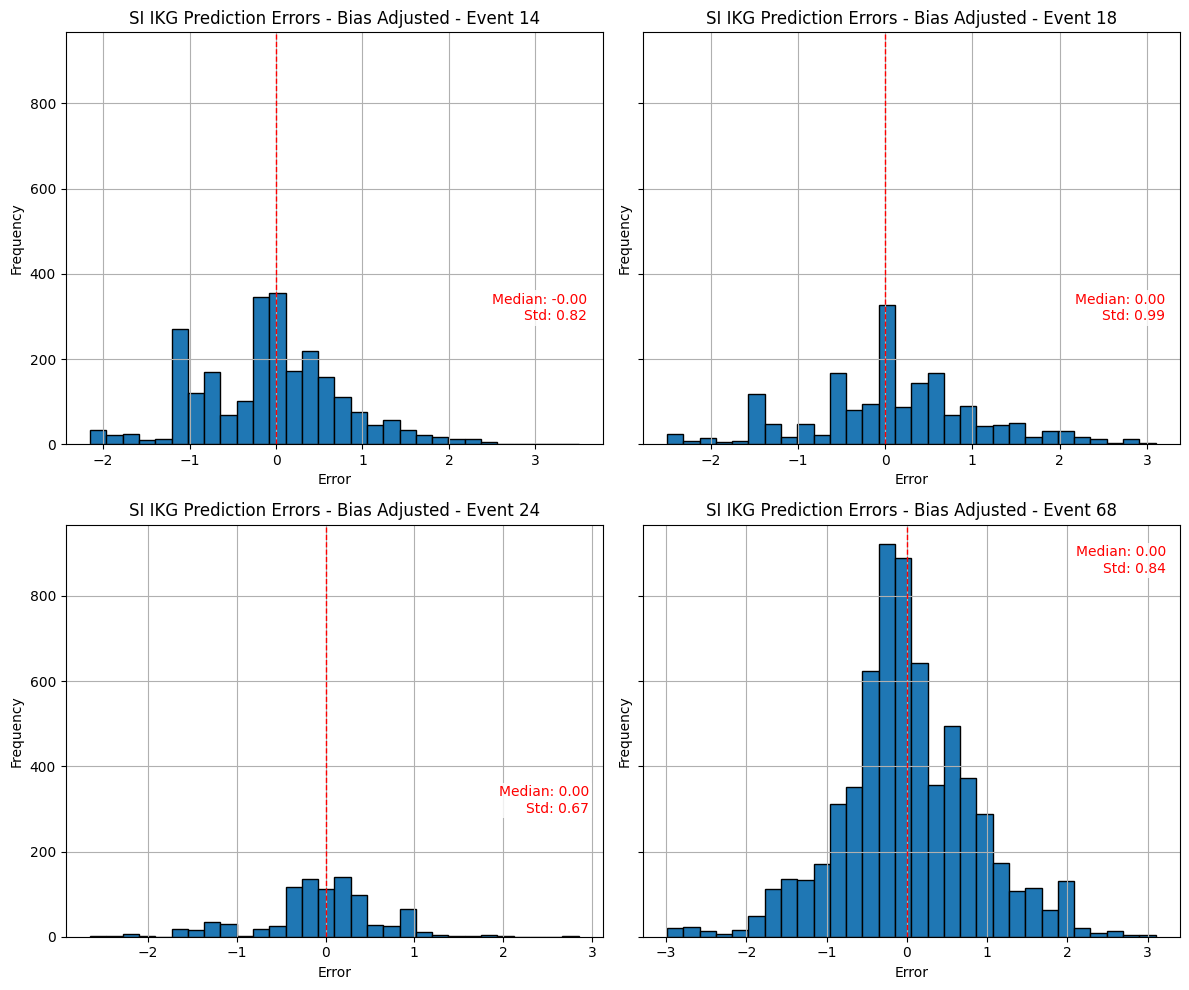

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_id in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekId"]==event_id]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_si_depth_bias_adjusted",
        title=f"SI IKG Prediction Errors - Bias Adjusted - Event {event_id}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.show()

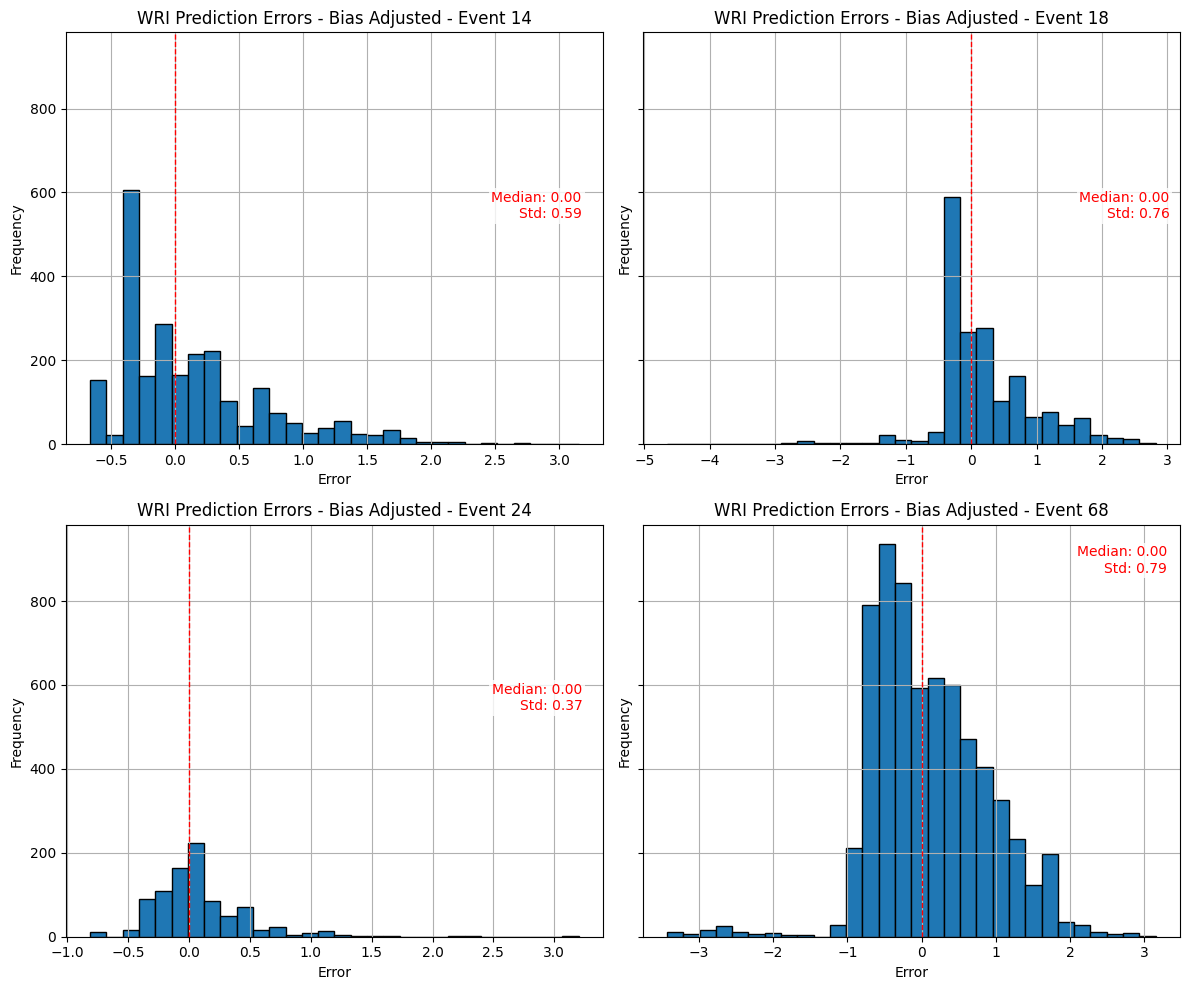

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_id in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekId"]==event_id]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_wri_depth_bias_adjusted",
        title=f"WRI Prediction Errors - Bias Adjusted - Event {event_id}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.show()

{'si': {'within_20': 0.3278159063383125, 'median_error': -2.7755575615628914e-17, 'median_absolute_error': 0.5, 'st_dev_residuals': 2.90785479364155, 'total_samples': 2477}, 'wri': {'within_20': 0.40088817117480824, 'median_error': 0.0, 'median_absolute_error': 0.35, 'st_dev_residuals': 1.2435938264598392, 'total_samples': 2477}}
{'si': {'within_20': 0.3266555370061213, 'median_error': 0.0, 'median_absolute_error': 0.5, 'st_dev_residuals': 4.565795455921223, 'total_samples': 1797}, 'wri': {'within_20': 0.3728436282693378, 'median_error': 0.0, 'median_absolute_error': 0.4, 'st_dev_residuals': 1.973405691399606, 'total_samples': 1797}}
{'si': {'within_20': 0.13474387527839643, 'median_error': 0.0, 'median_absolute_error': 0.35, 'st_dev_residuals': 3.256612722384023, 'total_samples': 898}, 'wri': {'within_20': 0.2984409799554566, 'median_error': 0.0, 'median_absolute_error': 0.19999999999999998, 'st_dev_residuals': 1.5690361598825273, 'total_samples': 898}}
{'si': {'within_20': 0.21391595

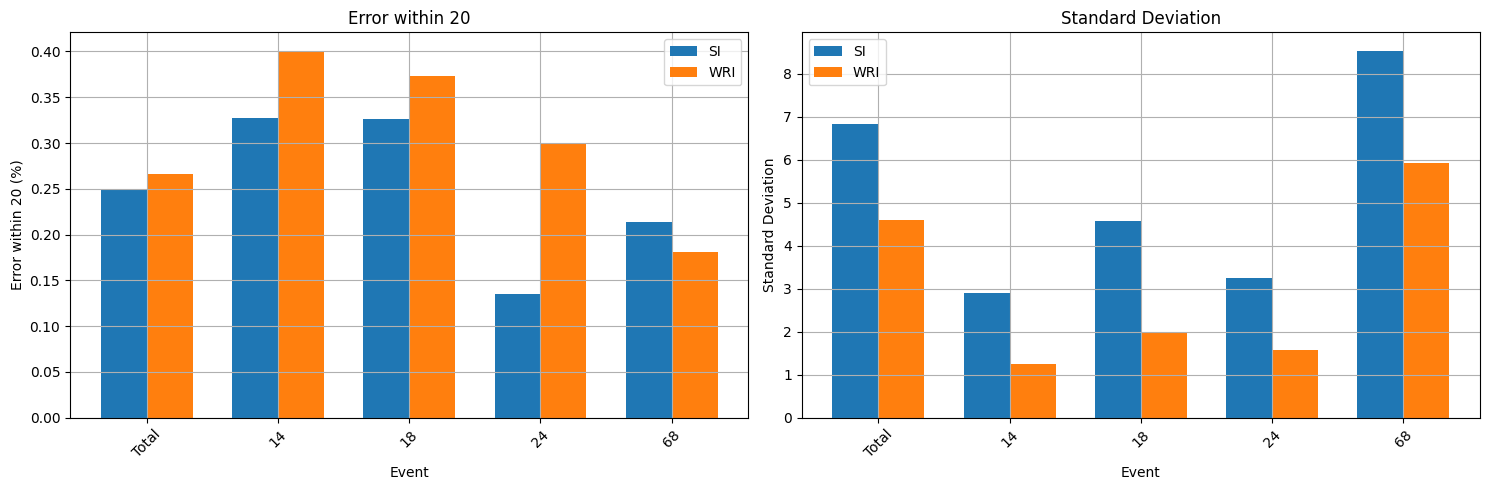

In [57]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_quality_metrics(df, events):
    """
    Create three plots showing different quality metrics for SI and WRI depth predictions.
    
    Args:
        df (pd.DataFrame): DataFrame containing the data
        events (list): List of event IDs to analyze
    """
    # Create figure with 3 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Prepare data for plotting
    metrics = {
        "Total": {
            "si": quality_metrics.get_metrics(df["measured_depth"], df["predicted_si_depth_bias_adjusted"]),
            "wri": quality_metrics.get_metrics(df["measured_depth"], df["predicted_wri_depth_bias_adjusted"])
        }
    }
    
    for event_id in events:
        _df = df[df["DogodekId"] == event_id]
        metrics[event_id] = {
            "si": quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth_bias_adjusted"]),
            "wri": quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth_bias_adjusted"])
        }
        print(metrics[event_id])
    
    # Extract metrics for plotting
    event_ids = list(metrics.keys())
    si_error_within_20 = [m["si"]["within_20"] for m in metrics.values()]
    wri_error_within_20 = [m["wri"]["within_20"] for m in metrics.values()]
    si_median_error = [m["si"]["median_error"] for m in metrics.values()]
    wri_median_error = [m["wri"]["median_error"] for m in metrics.values()]
    si_std_error = [m["si"]["st_dev_residuals"] for m in metrics.values()]
    wri_std_error = [m["wri"]["st_dev_residuals"] for m in metrics.values()]
    
    # Plot 1: Error within 20
    x = np.arange(len(event_ids))
    width = 0.35
    ax1.bar(x - width/2, si_error_within_20, width, label="SI")
    ax1.bar(x + width/2, wri_error_within_20, width, label="WRI")
    ax1.set_ylabel("Error within 20 (%)")
    ax1.set_xlabel("Event")
    ax1.set_title("Error within 20")
    ax1.set_xticks(x)
    ax1.set_xticklabels(event_ids, rotation=45)
    ax1.legend()
    ax1.grid()
    # Plot 2: Median Error
    # ax2.bar(x - width/2, si_median_error, width, label="SI")
    # ax2.bar(x + width/2, wri_median_error, width, label="WRI")
    # ax2.set_ylabel("Median Error")
    # ax2.set_title("Median Error")
    # ax2.set_xticks(x)
    # ax2.set_xticklabels(event_ids, rotation=45)
    # ax2.legend()
    
    # Plot 3: Standard Deviation
    ax2.bar(x - width/2, si_std_error, width, label="SI")
    ax2.bar(x + width/2, wri_std_error, width, label="WRI")
    ax2.set_ylabel("Standard Deviation")
    ax2.set_xlabel("Event")
    ax2.set_title("Standard Deviation")
    ax2.set_xticks(x)
    ax2.set_xticklabels(event_ids, rotation=45)
    ax2.legend()
    ax2.grid()
    
    plt.tight_layout()
    return fig

res = plot_quality_metrics(df, events)

----------

# Categorize measured_depth into 4 categories


In [58]:
df["depth_category"] = pd.cut(df["measured_depth"], bins=[0, 0.5, 1.5, 2.5], labels=[0.5, 1.5, 2.5])
# df.shape
# df.head()
# df.groupby("depth_category").mean()
# df.groupby("depth_category").mean()

In [59]:
df["depth_category"].value_counts().sort_index()


depth_category
0.5    4277
1.5    4334
2.5    1757
Name: count, dtype: int64

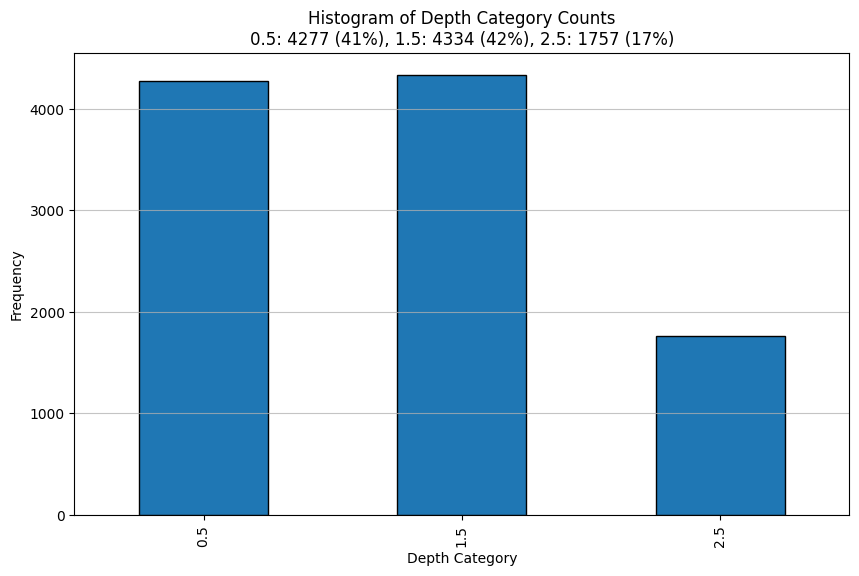

0.5: 4277 (41%), 1.5: 4334 (42%), 2.5: 1757 (17%)


In [60]:
value_counts = df["depth_category"].value_counts().sort_index()
value_counts.plot(kind="bar", edgecolor="black", figsize=(10, 6))

# Calculate relative percentages
total_count = value_counts.sum()
percentages = (value_counts / total_count) * 100

# Add text with percentages below the title
percent_text = ", ".join([f"{cat}: {count} ({percent:.0f}%)" for cat, count, percent in zip(value_counts.index, value_counts, percentages)])
plt.title(f"Histogram of Depth Category Counts\n{percent_text}")
# plt.title("Histogram of Depth Category Counts")
plt.xlabel("Depth Category")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()
print(percent_text)

<Axes: xlabel='depth_category', ylabel='predicted_si_depth'>

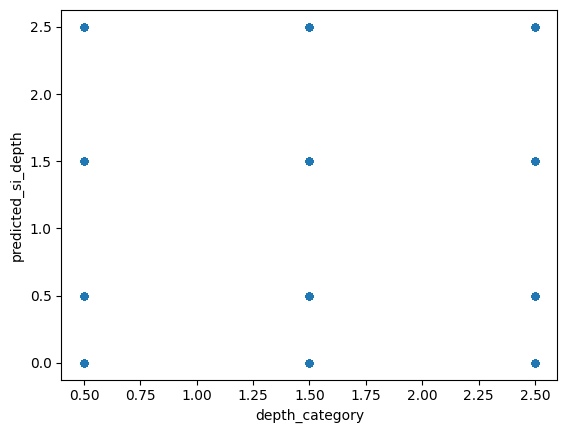

In [61]:
df.plot(x="depth_category", y="predicted_si_depth", kind="scatter")

In [77]:
def plot_confusion_matrix(df, true_column, predicted_column, title: str = "Confusion Matrix"):
    # First, let's bin the measured_depth into categories and do the same for predictions
    # Create categorical bins for the depths
    def categorize_depth(depth):
        if depth <= 0.5:
            return "0.5"
        elif depth <= 1.5:
            return "1.5"
        return "2.5"
    
    _df = df.copy()
    
    _df["depth_category_true"] = _df[true_column].apply(categorize_depth)
    _df["depth_category_pred"] = _df[predicted_column].apply(categorize_depth)

    # Calculate confusion matrix
    cm = confusion_matrix(_df["depth_category_true"], _df["depth_category_pred"])
    categories = ["0.5", "1.5", "2.5"]

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=categories, 
                yticklabels=categories)
    plt.title(title)
    plt.xlabel("Predicted Category")
    plt.ylabel("True Category")
    plt.show()

    # ---
    # Calculate metrics
    # ---
    accuracy = accuracy_score(_df["depth_category_true"], _df["depth_category_pred"])
    precision, recall, f1, support = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average=None
    )

    metrics_df = pd.DataFrame({
        "Category": ["0.5", "1.5", "2.5"],
        "Precision": precision,
        "Recall": recall,
        "Support": support
    })

    # Print overall accuracy
    print(f"Overall Classification Accuracy: {accuracy:.3f}\n")

    # Print per-category metrics
    print("Per-category metrics:")
    print(metrics_df.to_string(index=False))

    """
    Metrics explanation:
    - Accuracy: Proportion of correct predictions among total predictions
    - Precision: Proportion of correct positive predictions among all positive predictions for each category
    - Recall: Proportion of correct positive predictions among all actual positives for each category
    - Support: Number of samples in each category
    """
    

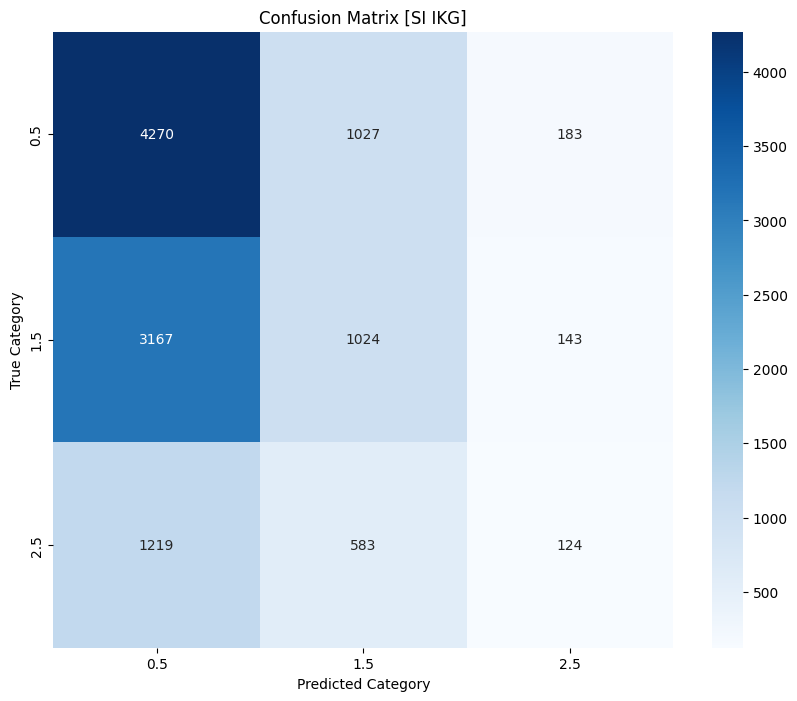

Overall Classification Accuracy: 0.461

Per-category metrics:
Category  Precision   Recall  Support
     0.5   0.493299 0.779197     5480
     1.5   0.388762 0.236271     4334
     2.5   0.275556 0.064382     1926


In [78]:
plot_confusion_matrix(df, "measured_depth", "predicted_si_depth", title="Confusion Matrix [SI IKG]")

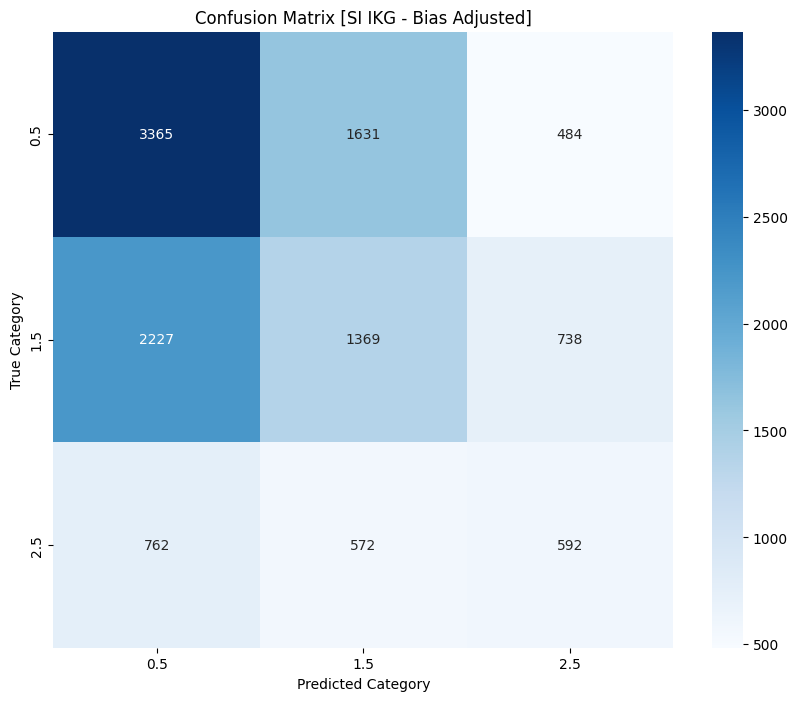

Overall Classification Accuracy: 0.454

Per-category metrics:
Category  Precision   Recall  Support
     0.5   0.529588 0.614051     5480
     1.5   0.383259 0.315874     4334
     2.5   0.326351 0.307373     1926


In [79]:
plot_confusion_matrix(df, "measured_depth", "predicted_si_depth_bias_adjusted", title="Confusion Matrix [SI IKG - Bias Adjusted]")

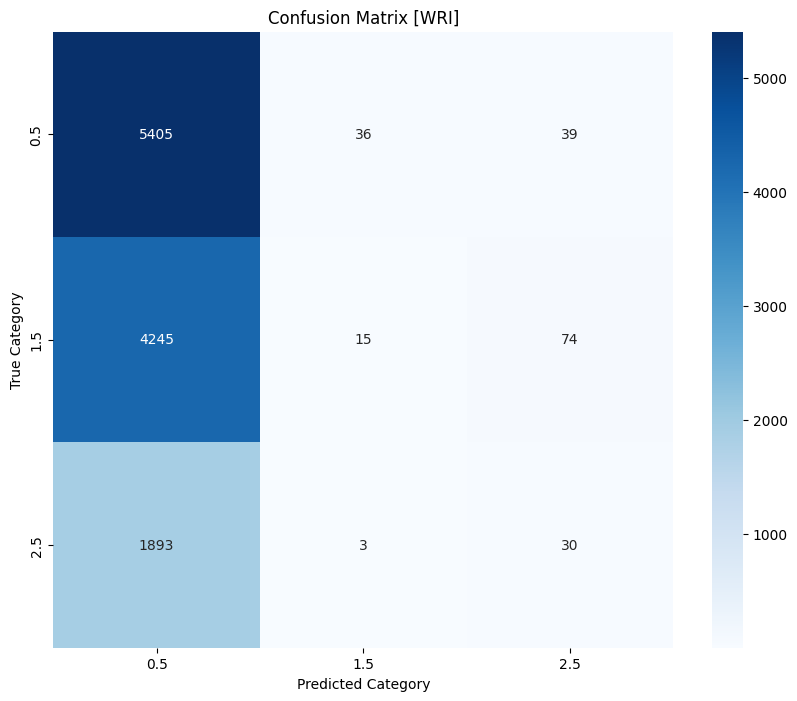

Overall Classification Accuracy: 0.464

Per-category metrics:
Category  Precision   Recall  Support
     0.5   0.468249 0.986314     5480
     1.5   0.277778 0.003461     4334
     2.5   0.209790 0.015576     1926


In [74]:
plot_confusion_matrix(df, "measured_depth", "predicted_wri_depth", title="Confusion Matrix [WRI]")

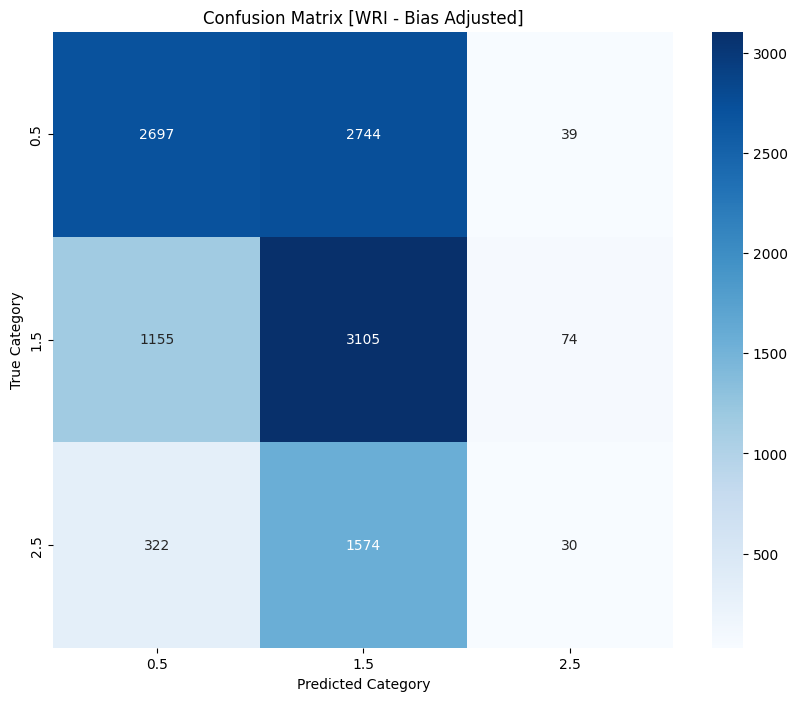

Overall Classification Accuracy: 0.497

Per-category metrics:
Category  Precision   Recall  Support
     0.5   0.646143 0.492153     5480
     1.5   0.418294 0.716428     4334
     2.5   0.209790 0.015576     1926


In [75]:
plot_confusion_matrix(df, "measured_depth", "predicted_wri_depth_bias_adjusted", title="Confusion Matrix [WRI - Bias Adjusted]")